# Recurrent Neural Network (RNN) - TensorFlow / Keras

In [4]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -----------------------------
# Reproducibility: Set seeds
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")

# -----------------------------
# Generate synthetic dataset
# -----------------------------
samples, seq_len, features = 1400, 30, 3
X = np.random.normal(size=(samples, seq_len, features)).astype("float32")

signal = (
    X[:, -10:, 0].mean(axis=1) +
    0.5 * X[:, :10, 1].mean(axis=1)
    )

y = (signal > 0.05).astype("int64")

# Train/test split
X_train, X_test = X[:1000], X[1000:]
y_train, y_test = y[:1000], y[1000:]

# -----------------------------
# Define RNN model
# -----------------------------
model = keras.Sequential([
    layers.Input(shape=(seq_len, features)),
    layers.SimpleRNN(32),
    layers.Dropout(0.2),
    layers.Dense(2, activation="softmax"),
    ])

model.compile(
    optimizer=keras.optimizers.AdamW(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    )

model.summary()

# -----------------------------
# Train model
# -----------------------------
model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64
    )

TensorFlow version: 2.20.0


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,218 (4.76 KB)

 Trainable params: 1,218 (4.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5050 - loss: 0.8205 - val_accuracy: 0.4950 - val_loss: 0.7494
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5830 - loss: 0.6992 - val_accuracy: 0.6400 - val_loss: 0.6357
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6870 - loss: 0.5762 - val_accuracy: 0.7300 - val_loss: 0.5253
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7530 - loss: 0.4878 - val_accuracy: 0.8000 - val_loss: 0.4547
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7920 - loss: 0.4320 - val_accuracy: 0.7875 - val_loss: 0.4483
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7830 - loss: 0.4355 - val_accuracy: 0.8300 - val_loss: 0.4157
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7980 - loss: 0.4034 - val_accuracy: 0.8175 - val_loss: 0.4133
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7990 - loss: 0.4028 - val_accuracy: 0.8225 - v

TensorFlow: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        80,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,674 (319.04 KB)

 Trainable params: 81,674 (319.04 KB)

 Non-trainable params: 0 (0.00 B)


Starting training on Sequential MNIST...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - accuracy: 0.8160 - loss: 0.5617 - val_accuracy: 0.9501 - val_loss: 0.1649
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9520 - loss: 0.1625 - val_accuracy: 0.9644 - val_loss: 0.1157
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.9668 - loss: 0.1130 - val_accuracy: 0.9727 - val_loss: 0.0832
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 79ms/step - accuracy: 0.9752 - loss: 0.0841 - val_accuracy: 0.9725 - val_loss: 0.0842
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - accuracy: 0.9800 - loss: 0.0700 - val_accuracy: 0.9787 - val_loss: 0.0668
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 84ms/step - accuracy: 0.9829 - loss: 0.0592 - val_accuracy: 0.9783 - val_loss: 0.0717
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - accuracy: 0.9849 - loss: 0.0511 - val_accuracy: 0.9805 - val_loss: 0.0626
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms

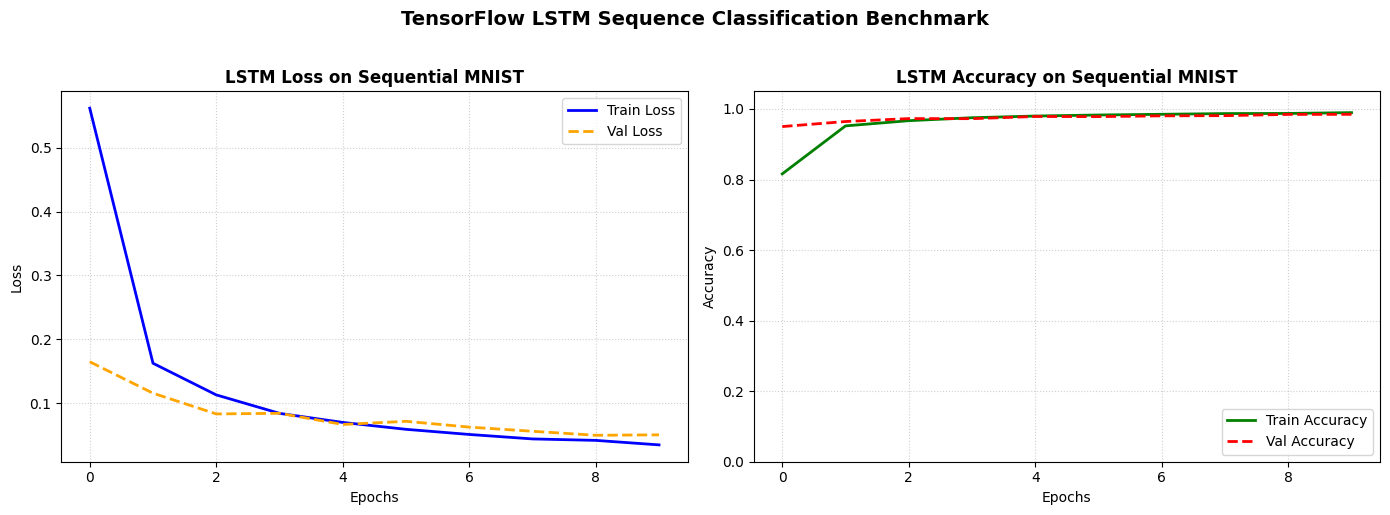

In [3]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf

# ── 0. REPRODUCIBILITY & SETUP ────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(f"TensorFlow: {tf.__version__}")

# ── 1. DATA PREPARATION (Sequential MNIST) ────────────────────────────────────
# We use the standard MNIST dataset, but treat it as sequence data.
# Each 28x28 image is treated as 28 sequences (rows) of 28 features (pixels).
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# The data is natively shaped (batch_size, 28, 28).
# This perfectly matches the RNN expected input: (batch_size, time_steps, features)

# ── 2. MODEL ARCHITECTURE ─────────────────────────────────────────────────────
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),

    # LSTM is vastly superior to SimpleRNN for remembering across 28 steps
    tf.keras.layers.LSTM(128, return_sequences=False),

    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

# ── 3. TRAINING PIPELINE ──────────────────────────────────────────────────────
print("\nStarting training on Sequential MNIST...")
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128
)

# ── 4. VISUALIZATION PIPELINE ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
ax1.plot(history.history["loss"], label="Train Loss", color="blue", lw=2)
ax1.plot(history.history["val_loss"], label="Val Loss", color="orange", lw=2, linestyle="--")
ax1.set_title("LSTM Loss on Sequential MNIST", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend(frameon=True)
ax1.grid(True, linestyle=":", alpha=0.6)

# Plot 2: Accuracy curves
ax2.plot(history.history["accuracy"], label="Train Accuracy", color="green", lw=2)
ax2.plot(history.history["val_accuracy"], label="Val Accuracy", color="red", lw=2, linestyle="--")
ax2.set_title("LSTM Accuracy on Sequential MNIST", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.0, 1.05)
ax2.legend(frameon=True, loc="lower right")
ax2.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("TensorFlow LSTM Sequence Classification Benchmark", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()